# Module 10: Time-Series Mastery
## Objective: Analyzing data that flows through time.

Unlike standard datasets, time-series data has an inherent order. In this module, 
we will master **Resampling** to change frequencies, **Lag Analysis** to 
understand historical impact, and **Stationarity** to identify predictable patterns.

### 1. Frequency Conversion (Resampling)
Resampling is similar to a `groupby` operation but specifically for time. 
* Use `.resample('M').mean()` to get **Monthly** averages.
* Use `.resample('W').sum()` to get **Weekly** totals.

In [1]:
import pandas as pd
import numpy as np

# Create 365 days of daily "Temperature" data
dates = pd.date_range(start='2024-01-01', periods=365, freq='D')
temp_data = np.random.normal(loc=25, scale=5, size=365)
ts_df = pd.DataFrame({'Temperature': temp_data}, index=dates)

# Downsampling: Daily -> Monthly Averages
monthly_avg = ts_df.resample('M').mean()

print("First 5 Monthly Averages:")
display(monthly_avg.head())

First 5 Monthly Averages:


,Temperature
2024-01-31,24.684384
2024-02-29,25.204419
2024-03-31,25.929934
2024-04-30,24.505637
2024-05-31,25.138725


### 2. Looking into the Past
To see how last month affects this month, we "shift" the data using `.shift()`. 
In agricultural analytics, a **Lag of 3 months** might represent the time between 
[cite_start]planting and harvest.

In [2]:
# Create a "Rainfall" column
ts_df['Rainfall'] = np.random.uniform(0, 100, size=365)

# Create a Lag Feature: "Last Month's Rainfall"
# We shift the data forward so today's row contains yesterday's value
ts_df['Rain_Lag_30D'] = ts_df['Rainfall'].shift(30)

print("Data showing the 30-day Lag:")
display(ts_df.iloc[30:35]) # Viewing where the lag starts appearing

Data showing the 30-day Lag:


,Temperature,Rainfall,Rain_Lag_30D
2024-01-31,16.443169,99.555991,77.227895
2024-02-01,29.102960,46.549152,40.167998
2024-02-02,16.695196,26.244881,7.535105
2024-02-03,28.020649,22.604746,70.168002
2024-02-04,39.095440,19.559616,50.491760


### 3. Identifying Trends
A **Rolling Mean** (Moving Average) is the best way to visually check for 
stationarity. If the rolling mean is a flat line, the data is likely 
stationary. [cite_start]If it slopes, there is a **Trend**.

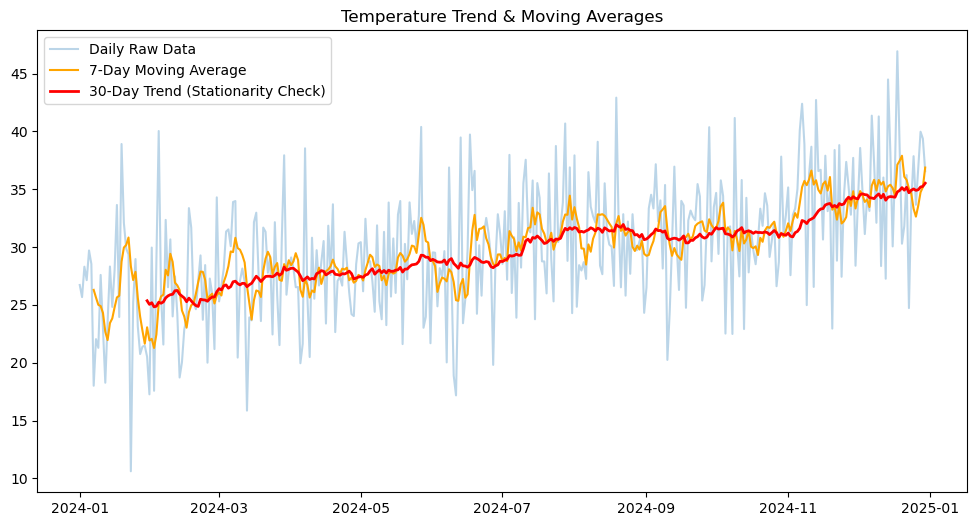

In [3]:
import matplotlib.pyplot as plt

# Adding a synthetic "Upward Trend" to the temperature
ts_df['Temp_Trend'] = ts_df['Temperature'] + np.linspace(0, 10, 365)

# Calculate 7-Day and 30-Day Moving Averages 
ts_df['7D_MA'] = ts_df['Temp_Trend'].rolling(window=7).mean()
ts_df['30D_MA'] = ts_df['Temp_Trend'].rolling(window=30).mean()

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(ts_df['Temp_Trend'], alpha=0.3, label='Daily Raw Data')
plt.plot(ts_df['7D_MA'], label='7-Day Moving Average', color='orange')
plt.plot(ts_df['30D_MA'], label='30-Day Trend (Stationarity Check)', color='red', linewidth=2)
plt.title("Temperature Trend & Moving Averages")
plt.legend()
plt.show()

### Student Exercise: The Seasonal Crop Forecast 
**Goal**: Identify if "Last Month's Humidity" predicts "This Month's Yield."
1. Generate 2 years (730 days) of daily **Humidity** and **Yield** data.
2. **Resample** the data to a **Weekly** frequency
3. Create a **Lag feature** for Humidity (1 week lag).
4. Use a **Rolling Mean** to determine if the Yield has a consistent 
   upward trend over the 2 years.
5. Calculate the **Correlation** between the Lagged Humidity and the 
   Current Yield.